# Random Sector Time-Series Visualization

This notebook visualizes full sector time-series sampled at random from:
- `data/data_1to7.csv`
- `data/data_original.csv`


In [1]:
from __future__ import annotations

from pathlib import Path
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

DATA_1TO7_PATH = ROOT / 'data' / 'data_1to7.csv'
DATA_ORIGINAL_PATH = ROOT / 'data' / 'data_original.csv'
PLOTS_DIR = ROOT / 'results' / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


N_RANDOM_SECTORS = 6
RANDOM_SEED = 42

FR_MONTHS = {
    'janvier': 1,
    'fevrier': 2,
    'mars': 3,
    'avril': 4,
    'mai': 5,
    'juin': 6,
    'juillet': 7,
    'aout': 8,
    'septembre': 9,
    'octobre': 10,
    'novembre': 11,
    'decembre': 12,
}
FR_WEEKDAYS = {'lundi', 'mardi', 'mercredi', 'jeudi', 'vendredi', 'samedi', 'dimanche'}

def _normalize_ascii(text: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

def _parse_french_date(value: object) -> pd.Timestamp | pd.NaT:
    if pd.isna(value):
        return pd.NaT
    s = _normalize_ascii(str(value).strip().lower())
    parts = s.split()
    if not parts:
        return pd.NaT
    if parts[0] in FR_WEEKDAYS:
        parts = parts[1:]
    if len(parts) < 3:
        return pd.NaT
    day_s, month_s, year_s = parts[0], parts[1], parts[2]
    if not day_s.isdigit() or not year_s.isdigit():
        return pd.NaT
    month = FR_MONTHS.get(month_s)
    if month is None:
        return pd.NaT
    try:
        return pd.Timestamp(year=int(year_s), month=int(month), day=int(day_s))
    except ValueError:
        return pd.NaT

def parse_mixed_timestamp(series: pd.Series) -> pd.Series:
    text = series.astype(str)
    # Avoid noisy dateutil fallback warnings on French free-text timestamps.
    has_letters = text.str.contains(r'[A-Za-zÀ-ÿ]', regex=True, na=False)
    parsed = pd.to_datetime(series.where(~has_letters), errors='coerce')
    if has_letters.any():
        parsed.loc[has_letters] = series.loc[has_letters].map(_parse_french_date)
    return parsed

print('Project root:', ROOT)
print('data_1to7 path:', DATA_1TO7_PATH)
print('data_original path:', DATA_ORIGINAL_PATH)
print('plots dir:', PLOTS_DIR)


Project root: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository
data_1to7 path: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_1to7.csv
data_original path: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/data/data_original.csv
plots dir: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots


In [2]:
df_1to7 = pd.read_csv(DATA_1TO7_PATH)
df_original = pd.read_csv(DATA_ORIGINAL_PATH)

for df in (df_1to7, df_original):
    if 'timestamp' not in df.columns:
        raise ValueError('Expected a timestamp column in both datasets.')

df_1to7['timestamp'] = parse_mixed_timestamp(df_1to7['timestamp'])
df_original['timestamp'] = parse_mixed_timestamp(df_original['timestamp'])

na_1to7 = int(df_1to7['timestamp'].isna().sum())
na_original = int(df_original['timestamp'].isna().sum())
print(f'NaT timestamps | data_1to7: {na_1to7} | data_original: {na_original}')

sector_cols_1to7 = [c for c in df_1to7.columns if c != 'timestamp']
sector_cols_original = [c for c in df_original.columns if c != 'timestamp']
common_sectors = sorted(set(sector_cols_1to7).intersection(sector_cols_original))

if not common_sectors:
    raise ValueError('No common sector columns found between datasets.')

rng = np.random.default_rng(RANDOM_SEED)
sample_size = min(N_RANDOM_SECTORS, len(common_sectors))
selected_sectors = sorted(rng.choice(common_sectors, size=sample_size, replace=False).tolist())

print('data_1to7 shape:', df_1to7.shape)
print('data_original shape:', df_original.shape)
print('Same sectors are used for both plots, but each dataset is plotted independently.')
print('common sectors:', len(common_sectors))
print('selected random sectors:', selected_sectors)


NaT timestamps | data_1to7: 0 | data_original: 0
data_1to7 shape: (1351, 87)
data_original shape: (128, 87)
Same sectors are used for both plots, but each dataset is plotted independently.
common sectors: 86
selected random sectors: ['T70722C', 'T70744B', 'T78258B', 'T78264B', 'T78271C', 'T78280B']


In [3]:
def plot_full_series_grid(
    df: pd.DataFrame,
    sectors: list[str],
    title: str,
    color: str,
    save_path: Path | None = None,
) -> None:
    n = len(sectors)
    ncols = 2
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4.2 * nrows), sharex=False)
    axes = np.atleast_1d(axes).reshape(-1)

    for i, sector in enumerate(sectors):
        ax = axes[i]
        ax.plot(df['timestamp'], pd.to_numeric(df[sector], errors='coerce'), color=color, linewidth=1.2)
        ax.set_title(sector)
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Traffic')
        ax.grid(alpha=0.25)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


Saved: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/random_full_sectors_data_1to7_seed42.png


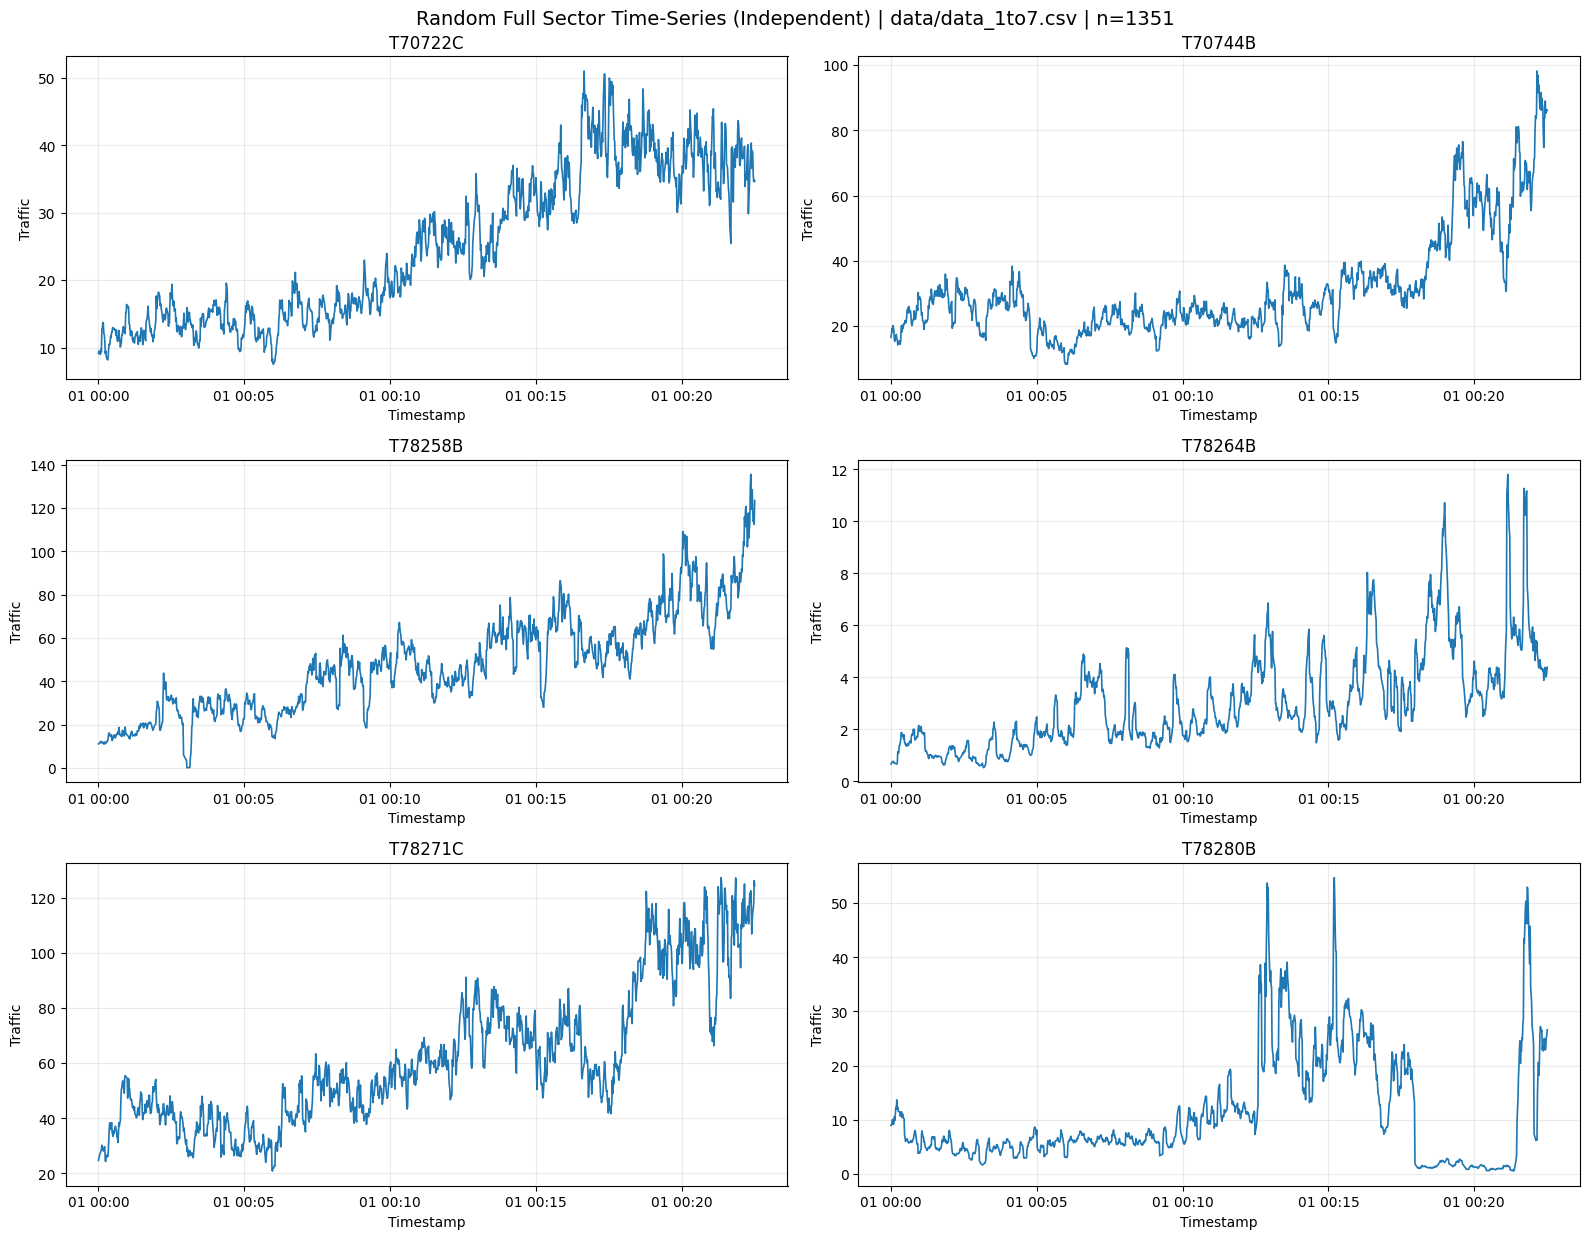

In [4]:
plot_full_series_grid(
    df=df_1to7,
    sectors=selected_sectors,
    title=f'Random Full Sector Time-Series (Independent) | data/data_1to7.csv | n={len(df_1to7)}',
    color='tab:blue',
    save_path=PLOTS_DIR / f'random_full_sectors_data_1to7_seed{RANDOM_SEED}.png',
)


Saved: /Users/colinminini/Desktop/SCOC_ICE/LLM6G-Repository/results/plots/random_full_sectors_data_original_seed42.png


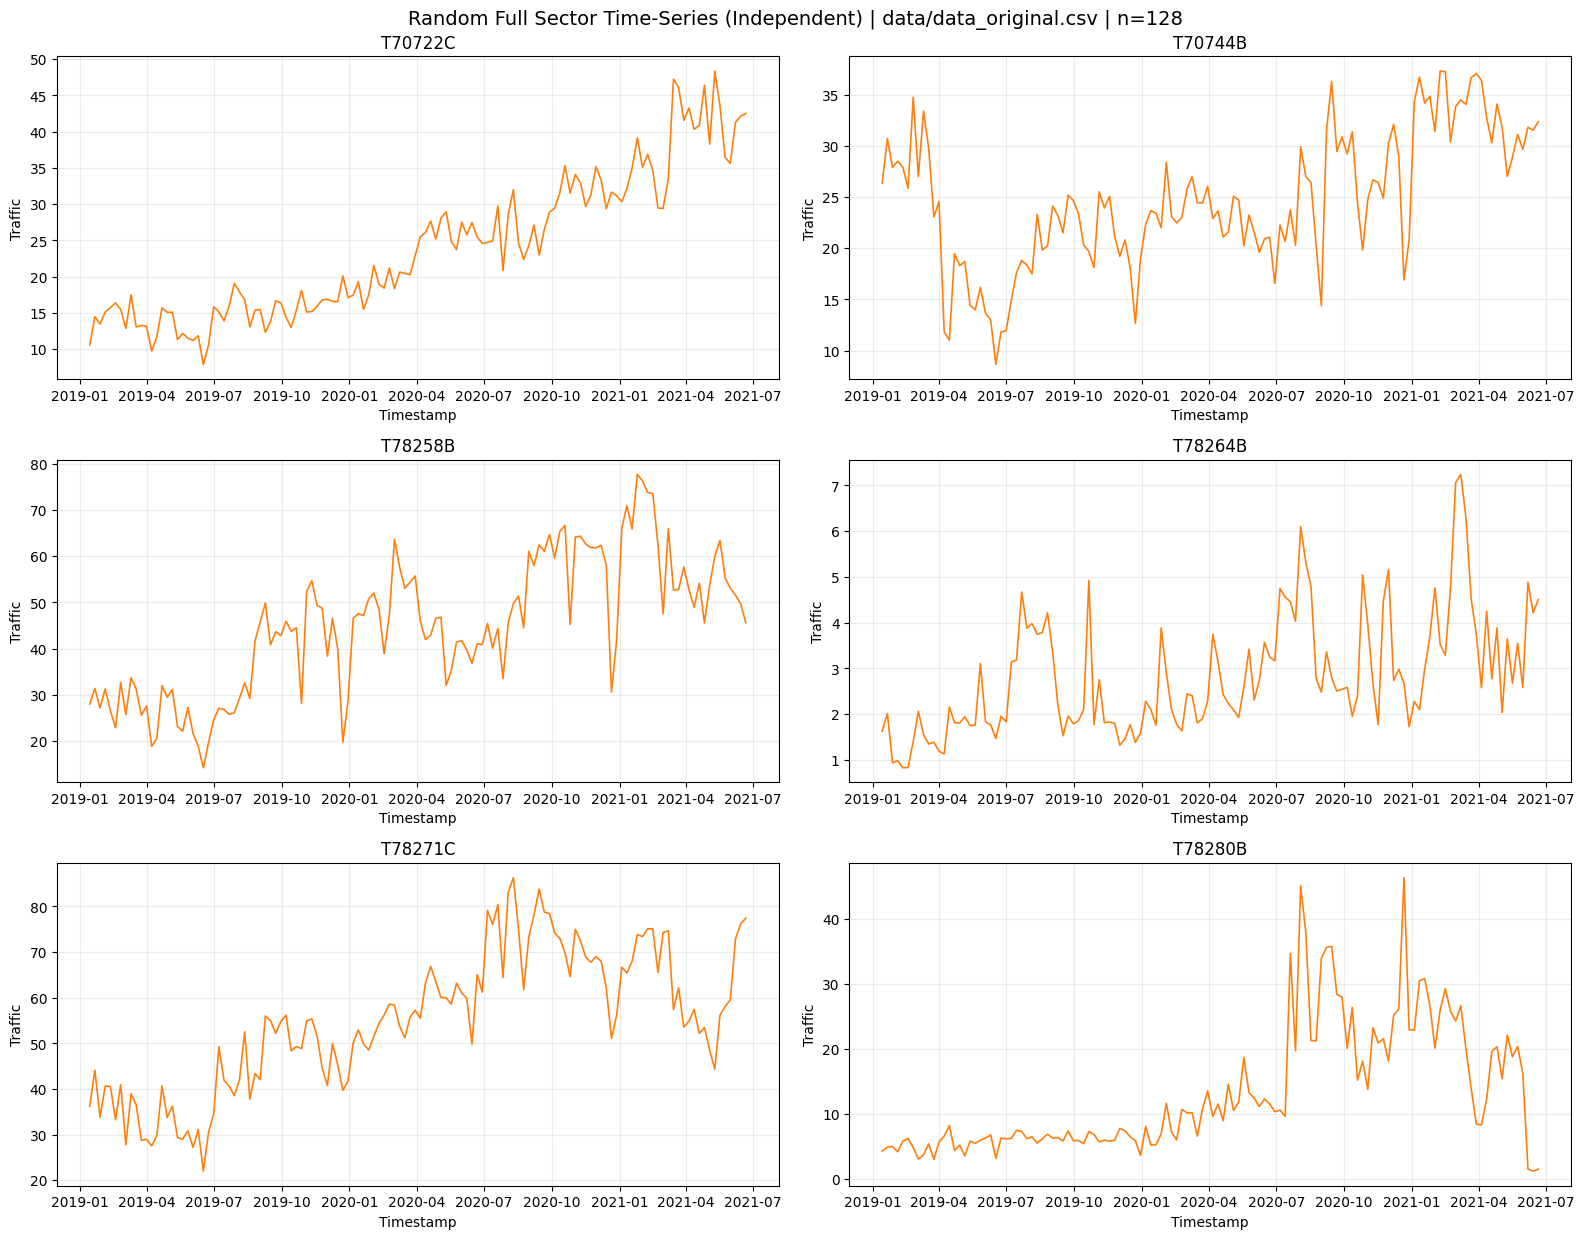

In [5]:
plot_full_series_grid(
    df=df_original,
    sectors=selected_sectors,
    title=f'Random Full Sector Time-Series (Independent) | data/data_original.csv | n={len(df_original)}',
    color='tab:orange',
    save_path=PLOTS_DIR / f'random_full_sectors_data_original_seed{RANDOM_SEED}.png',
)


In [6]:
print('No overlay plot is generated because data_1to7 and data_original have different lengths.')
print('Both independent figures above use the same randomly selected sectors for a fair visual comparison.')


No overlay plot is generated because data_1to7 and data_original have different lengths.
Both independent figures above use the same randomly selected sectors for a fair visual comparison.
